<a href="https://colab.research.google.com/github/spierro01/Electron-proton-classifier/blob/main/electron_proton_classifier_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import glob
# prendo tutti i file degli elettroni e protoni
files_e = glob.glob("/content/drive/MyDrive/H5_FILES/electron__FTFP_BERT/*.pkl")
files_p = glob.glob("/content/drive/MyDrive/H5_FILES/proton__FTFP_BERT/*.pkl")

# carico e unisco tutti i file degli elettroni
df_electron = pd.concat(
    [pd.read_pickle(f) for f in files_e],
    ignore_index=True
)

# carico e unisco tutti i file dei protoni
df_proton = pd.concat(
    [pd.read_pickle(f) for f in files_p],
    ignore_index=True
)


In [19]:
# assegno le etichette: 0 = elettrone, 1 = protone
df_electron["label"] = 0
df_proton["label"] = 1



In [20]:
# unisco tutto in un unico dataset
df_all = pd.concat([df_electron, df_proton], ignore_index=True)


In [21]:
# scelgo le feature per il modello
features = [
"TR1_PMT_ADC_HG0",
"TR1_PMT_ADC_HG1",
"TR1_PMT_ADC_HG2",
"TR1_PMT_ADC_HG3",
"TR1_PMT_ADC_HG4",
"TR1_PMT_ADC_HG5",
"TR1_PMT_ADC_HG6",
"TR1_PMT_ADC_HG7",
"TR1_PMT_ADC_HG8",
"TR1_PMT_ADC_HG9",
"TR2_PMT_ADC_HG0",
"TR2_PMT_ADC_HG1",
"TR2_PMT_ADC_HG2",
"TR2_PMT_ADC_HG3",
"TR2_PMT_ADC_HG4",
"TR2_PMT_ADC_HG5",
"TR2_PMT_ADC_HG6",
"TR2_PMT_ADC_HG7",
"RAN_PMT_ADC_HG0",
"RAN_PMT_ADC_HG1",
"RAN_PMT_ADC_HG2",
"RAN_PMT_ADC_HG3",
"RAN_PMT_ADC_HG4",
"RAN_PMT_ADC_HG5",
"RAN_PMT_ADC_HG6",
"RAN_PMT_ADC_HG7",
"RAN_PMT_ADC_HG8",
"RAN_PMT_ADC_HG9",
"RAN_PMT_ADC_HG10",
"RAN_PMT_ADC_HG11",
"RAN_PMT_ADC_HG12",
"RAN_PMT_ADC_HG13",
"RAN_PMT_ADC_HG14",
"RAN_PMT_ADC_HG15",
"RAN_PMT_ADC_HG16",
"RAN_PMT_ADC_HG17",
"RAN_PMT_ADC_HG18",
"RAN_PMT_ADC_HG19",
"RAN_PMT_ADC_HG20",
"RAN_PMT_ADC_HG21",
"RAN_PMT_ADC_HG22",
"RAN_PMT_ADC_HG23",
"EN1_PMT_ADC_HG0",
"EN1_PMT_ADC_HG1",
"EN1_PMT_ADC_HG2",
"EN1_PMT_ADC_HG3",
"EN1_PMT_ADC_HG4",
"EN1_PMT_ADC_HG5",
"EN2_PMT_ADC_HG0",
"EN2_PMT_ADC_HG1",
"EN2_PMT_ADC_HG2",
"EN2_PMT_ADC_HG3",
"EN2_PMT_ADC_HG4",
"EN2_PMT_ADC_HG5",
"BOT_PMT_ADC_HG0",
"BOT_PMT_ADC_HG1",
"LAT_PMT_ADC_HG0",
"LAT_PMT_ADC_HG1",
"LAT_PMT_ADC_HG2",
"LAT_PMT_ADC_HG3",
"LAT_PMT_ADC_HG4",
"LAT_PMT_ADC_HG5",
"LAT_PMT_ADC_HG6",
"LAT_PMT_ADC_HG7",
"TR1_PMT_ADC_LG0",
"TR1_PMT_ADC_LG1",
"TR1_PMT_ADC_LG2",
"TR1_PMT_ADC_LG3",
"TR1_PMT_ADC_LG4",
"TR1_PMT_ADC_LG5",
"TR1_PMT_ADC_LG6",
"TR1_PMT_ADC_LG7",
"TR1_PMT_ADC_LG8",
"TR1_PMT_ADC_LG9",
"TR2_PMT_ADC_LG0",
"TR2_PMT_ADC_LG1",
"TR2_PMT_ADC_LG2",
"TR2_PMT_ADC_LG3",
"TR2_PMT_ADC_LG4",
"TR2_PMT_ADC_LG5",
"TR2_PMT_ADC_LG6",
"TR2_PMT_ADC_LG7",
"RAN_PMT_ADC_LG0",
"RAN_PMT_ADC_LG1",
"RAN_PMT_ADC_LG2",
"RAN_PMT_ADC_LG3",
"RAN_PMT_ADC_LG4",
"RAN_PMT_ADC_LG5",
"RAN_PMT_ADC_LG6",
"RAN_PMT_ADC_LG7",
"RAN_PMT_ADC_LG8",
"RAN_PMT_ADC_LG9",
"RAN_PMT_ADC_LG10",
"RAN_PMT_ADC_LG11",
"RAN_PMT_ADC_LG12",
"RAN_PMT_ADC_LG13",
"RAN_PMT_ADC_LG14",
"RAN_PMT_ADC_LG15",
"RAN_PMT_ADC_LG16",
"RAN_PMT_ADC_LG17",
"RAN_PMT_ADC_LG18",
"RAN_PMT_ADC_LG19",
"RAN_PMT_ADC_LG20",
"RAN_PMT_ADC_LG21",
"RAN_PMT_ADC_LG22",
"RAN_PMT_ADC_LG23",
"EN1_PMT_ADC_LG0",
"EN1_PMT_ADC_LG1",
"EN1_PMT_ADC_LG2",
"EN1_PMT_ADC_LG3",
"EN1_PMT_ADC_LG4",
"EN1_PMT_ADC_LG5",
"EN2_PMT_ADC_LG0",
"EN2_PMT_ADC_LG1",
"EN2_PMT_ADC_LG2",
"EN2_PMT_ADC_LG3",
"EN2_PMT_ADC_LG4",
"EN2_PMT_ADC_LG5",
"BOT_PMT_ADC_LG0",
"BOT_PMT_ADC_LG1",
"LAT_PMT_ADC_LG0",
"LAT_PMT_ADC_LG1",
"LAT_PMT_ADC_LG2",
"LAT_PMT_ADC_LG3",
"LAT_PMT_ADC_LG4",
"LAT_PMT_ADC_LG5",
"LAT_PMT_ADC_LG6",
"LAT_PMT_ADC_LG7",
"TR1_posx",
"TR1_posy",
"TR1_posz",
"TR2_posx",
"TR2_posy",
"TR2_posz",
"RAN_posx1",
"RAN_posx2",
"RAN_posx3",
"RAN_posx4",
"RAN_posx5",
"RAN_posx6",
"RAN_posx7",
"RAN_posx8",
"RAN_posx9",
"RAN_posx10",
"RAN_posx11",
"RAN_posx12",
"RAN_posy1",
"RAN_posy2",
"RAN_posy3",
"RAN_posy4",
"RAN_posy5",
"RAN_posy6",
"RAN_posy7",
"RAN_posy8",
"RAN_posy9",
"RAN_posy10",
"RAN_posy11",
"RAN_posy12",
"RAN_posz1",
"RAN_posz2",
"RAN_posz3",
"RAN_posz4",
"RAN_posz5",
"RAN_posz6",
"RAN_posz7",
"RAN_posz8",
"RAN_posz9",
"RAN_posz10",
"RAN_posz11",
"RAN_posz12",
"EN1_posx",
"EN1_posy",
"EN1_posz",
"EN2_posx",
"EN2_posy",
"EN2_posz",
"BOT_posx",
"BOT_posy",
"BOT_posz",
"LAT_posx",
"LAT_posy",
"LAT_posz",
"x1",
"y1",
"x2",
"y2",
"x3",
"y3",
"cls_res_x1",
"cls_res_y1",
"csize1",
"cls_res_x2",
"cls_res_y2",
"csize2",
"cls_res_x3",
"cls_res_y3",
"csize3",
"phi",
"theta"
]

# matrice input (X) e target (y)
X = df_all[features].values
y = df_all["label"].values


In [22]:
# split: 80% train+val, 20% test finale
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)


In [73]:
# scaling (normalizzazione feature)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [74]:
#converto tensori Pytorch
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

#creo Dataloader
train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)
test_dataset  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64)
test_loader  = DataLoader(test_dataset, batch_size=64)

device = "cuda" if torch.cuda.is_available() else "cpu"

/tmp/ipykernel_2059/1680126173.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.long)
/tmp/ipykernel_2059/1680126173.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val = torch.tensor(y_val, dtype=torch.long)
/tmp/ipykernel_2059/1680126173.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = torch.tensor(y_test, dtype=torch.long)


In [76]:
#definisco rete neurale
class NeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.net(x)

#creo il modello
model = NeuralNetwork(X_train.shape[1]).to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4   # regolarizzazione
)


In [77]:
#funzione di training
def train_epoch():
    model.train()
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

def evaluate(loader):
    model.eval()
    loss_total, correct = 0, 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)

            pred = model(X)
            loss_total += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).float().sum().item()

    loss_total /= len(loader)   #loss media
    accuracy = correct / len(loader.dataset)   #accuracy

    return loss_total, accuracy

In [46]:
train_losses = []
val_losses = []

best_val_loss = np.inf #migliore loss finora
patience = 5  #numero epoche senza miglioramento
counter = 0

epochs = 50

for epoch in range(epochs):

    train_epoch()

    train_loss, _ = evaluate(train_loader)
    val_loss, val_acc = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Val={val_loss:.4f}")

    # early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        best_model = model.state_dict()
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping!")
            break

# carico miglior modello
model.load_state_dict(best_model)

Epoch 1: Train=0.4251, Val=0.4282
Epoch 2: Train=0.3999, Val=0.4032
Epoch 3: Train=0.3872, Val=0.3904
Epoch 4: Train=0.3724, Val=0.3778
Epoch 5: Train=0.3694, Val=0.3759
Epoch 6: Train=0.3616, Val=0.3700
Epoch 7: Train=0.3583, Val=0.3675
Epoch 8: Train=0.3565, Val=0.3658
Epoch 9: Train=0.3574, Val=0.3673
Epoch 10: Train=0.3537, Val=0.3634
Epoch 11: Train=0.3491, Val=0.3597
Epoch 12: Train=0.3501, Val=0.3608
Epoch 13: Train=0.3515, Val=0.3620
Epoch 14: Train=0.3475, Val=0.3597
Epoch 15: Train=0.3441, Val=0.3560
Epoch 16: Train=0.3468, Val=0.3584
Epoch 17: Train=0.3425, Val=0.3544
Epoch 18: Train=0.3419, Val=0.3540
Epoch 19: Train=0.3378, Val=0.3505
Epoch 20: Train=0.3375, Val=0.3510
Epoch 21: Train=0.3410, Val=0.3542
Epoch 22: Train=0.3386, Val=0.3522
Epoch 23: Train=0.3389, Val=0.3524
Epoch 24: Train=0.3371, Val=0.3503
Epoch 25: Train=0.3366, Val=0.3519
Epoch 26: Train=0.3326, Val=0.3466
Epoch 27: Train=0.3319, Val=0.3458
Epoch 28: Train=0.3336, Val=0.3484
Epoch 29: Train=0.3300, Val=0

<All keys matched successfully>

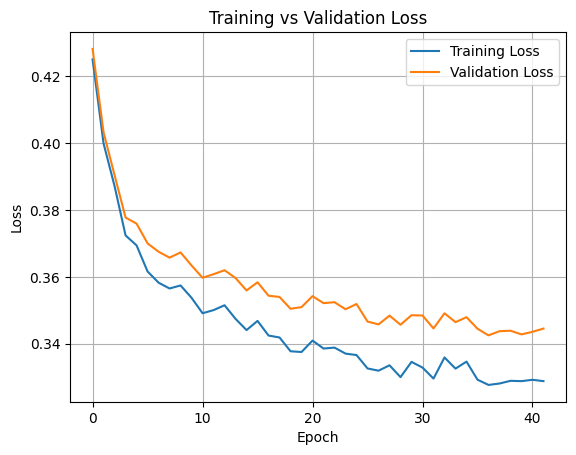

In [48]:
plt.figure()
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [47]:
y_true = []
y_pred = []
y_score = []

import torch.nn.functional as F

model.eval()
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)

        outputs = model(X)
        probs = F.softmax(outputs, dim=1) #probabilità

        preds = outputs.argmax(1) #classe predetta

        y_true.extend(y.numpy()) #etichette vere
        y_pred.extend(preds.cpu().numpy()) #predizioni
        y_score.extend(probs[:,1].cpu().numpy()) #probabilità protone

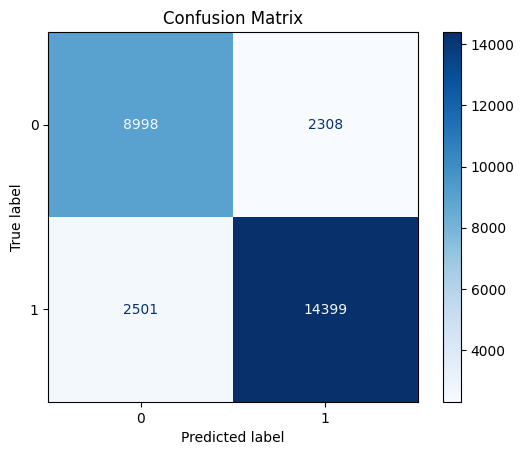

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Electron", "Proton"]  # 0 = Electron, 1 = Proton
)

disp.plot(cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()


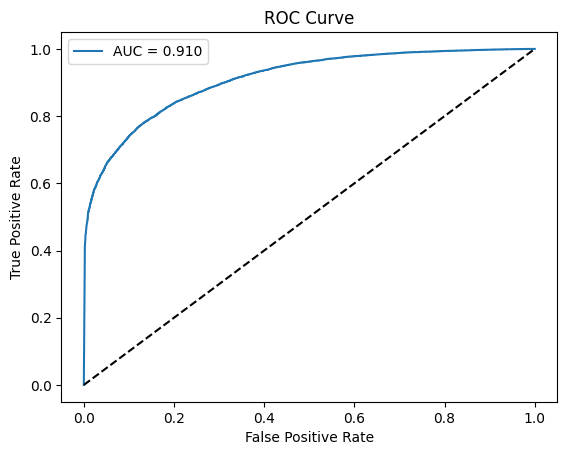

In [43]:
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc

y_score = []

with torch.no_grad():
    for X, _ in test_loader:
        X = X.to(device)
        outputs = model(X)
        probs = F.softmax(outputs, dim=1)
        y_score.extend(probs[:,1].cpu().numpy())

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

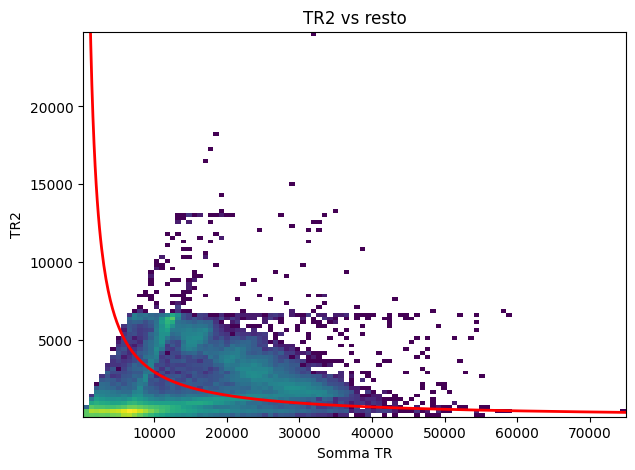

In [79]:
# colonne TR1
tr1_cols = [c for c in df_all.columns if "TR1" in c and "PMT_ADC_HG" in c]

# colonne TR2
tr2_cols = [c for c in df_all.columns if "TR2" in c and "PMT_ADC_HG" in c]

# colonne RAN
ran_cols = [c for c in df_all.columns if "RAN" in c and "PMT_ADC_HG" in c]

# creo le somme separate
df_all["TR1_sum"] = df_all[tr1_cols].sum(axis=1)
df_all["TR2_sum"] = df_all[tr2_cols].sum(axis=1)
df_all["RAN_sum"] = df_all[ran_cols].sum(axis=1)

import numpy as np
from matplotlib.colors import LogNorm

# Definisco la funzione di taglio iperbolica
def cut_function(x, a, b, c):
    return a / (x + b) + c

# Parametri iniziali per la funzione di taglio
a = 3e7
b = -0.005
c = -5e1

# Calcolo le variabili per il plot
somma_tr = df_all[['TR1_sum', 'TR2_sum', 'RAN_sum']].sum(axis=1)
tr2 = df_all['TR2_sum']

plt.figure(figsize=(7,5))

# Plot the 2D histogram
plt.hist2d(somma_tr, tr2, bins=100, norm=LogNorm())

# Calcolo i valori per la curva iperbolica
x_vals = np.linspace(somma_tr.min(), somma_tr.max(), 500)
y_vals = cut_function(x_vals, a, b, c)

# Plotto la curva iperbolica in rosso
plt.plot(x_vals, y_vals, color='red', linewidth=2, label='Funzione di Separazione')

plt.xlabel("Somma TR")
plt.ylabel("TR2")
plt.title("TR2 vs resto")
plt.show()

In [78]:
mask_electrons = tr2 < cut_function(somma_tr, a, b, c)
mask_protons = ~mask_electrons

df_electrons_cut = df_all[mask_electrons]
df_protons_cut = df_all[mask_protons]

print(f"Number of classified electrons: {len(df_electrons_cut)}")
print(f"Number of classified protons: {len(df_protons_cut)}")

Number of classified electrons: 120382
Number of classified protons: 20646
